### SINDy-SHRED applied to SST dataset

This iPython notebook gives an introductory walkthrough to using SHRED models.  The dataset we consider is weekly mean sea-surface temperature as given by the NOAA Optimum Interpolation SST V2 dataset (https://psl.noaa.gov/data/gridded/data.noaa.oisst.v2.html).

SHRED (SHallow REcurrent Decoder) models are a network architecture that merges a recurrent layer (LSTM) with a shallow decoder network (SDN) to reconstruct high-dimensional spatio-temporal fields from a trajectory of sensor measurements of the field. More formally, the SHRED architecture can be written as
$$ \mathcal {H} \left( \{ y_i \} _{i=t-k}^t \right) = \mathcal {F} \left( \mathcal {G} \left( \{ y_i \} _{i=t-k}^t \right) ; W_{RN}) ; W_{SD} \right)$$
where $\mathcal F$ is a feed forward network parameterized by weights $W_{SD}$, $\mathcal G$ is a LSTM network parameterized by weights $W_{RN}$, and $\{ y_i \} _{i=t-k}^t$ is a trajectory of sensor measurements of a high-dimensional spatio-temporal field $\{ x_i \} _{i=t-k}^t$.

SINDy-SHRED further extends the SHRED architecture by integrating **Sparse Identification of Nonlinear Dynamics (SINDy)** into the recurrent decoder framework. The key idea is to enforce a **parsimonious latent space representation**, where the dynamics of the latent variables are governed by a **sparse set of basis functions**.

More formally, SINDy-SHRED introduces an additional inductive bias:

$$\dot{z} = \Theta(z) \xi$$

where:

- $z = \mathcal{G} \left( \{ y_i \} _{i=t-k}^t \right)$ represents the **latent space variables** extracted by the LSTM encoder.
- $\Theta(z)$ is a **library of candidate nonlinear functions**.
- $\xi$ is a **sparse coefficient matrix** that determines the governing equations.

This combination enables **interpretable spatio-temporal modeling** by ensuring that the learned representations adhere to a **governing law**, making the method suitable for **data-driven discovery of dynamical systems** from high-dimensional, noisy observations.

In this notebook, we will walk through the application of **SINDy-SHRED** on the **weekly mean sea-surface temperature (SST) dataset**, demonstrating how the model can **learn a reduced-order latent representation** and **recover the governing equations** that describe the SST evolution.

We first randomly select 3 sensor locations and set the trajectory length (lags) to 52, corresponding to one year of measurements.

In [1]:
# Clone GitHub repository
!git clone https://github.com/fmenol/sindy-shred.git
!pip install pysindy==1.7.5 numpy==1.23.5 pandas==1.5.3 scipy==1.13.1 scikit-learn==1.5.2

Cloning into 'sindy-shred'...
remote: Enumerating objects: 119, done.
remote: Counting objects: 100% (67/67), done.
remote: Compressing objects: 100% (40/40), done.
remote: Total 119 (delta 35), reused 52 (delta 25), pack-reused 52 (from 1)
Receiving objects: 100% (119/119), 65.40 MiB | 12.39 MiB/s, done.
Resolving deltas: 100% (44/44), done.
Error downloading object: Data/SST_data.mat (5c49c48): Smudge error: Error downloading Data/SST_data.mat (5c49c487d48183b9ec6e6e0a8f3044c964c5731ed8a00b8074f37f395264b0e8): batch response: Git LFS is disabled for this repository.

Errors logged to /content/sindy-shred/.git/lfs/logs/20250429T120100.120409625.log
Use `git lfs logs last` to view the log.
error: external filter 'git-lfs filter-process' failed
fatal: Data/SST_data.mat: smudge filter lfs failed
You can inspect what was checked out with 'git status'
and retry with 'git restore --source=HEAD :/'

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━

In [1]:
# Add the repressilator data
%cd sindy-shred
!pip install gdown -q
!gdown --id 1CBvH5qtWqBuiQIavL3l9ESZYKFmdyzry -O ./Data/

/content/sindy-shred
/usr/local/lib/python3.11/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1CBvH5qtWqBuiQIavL3l9ESZYKFmdyzry
To: /content/sindy-shred/Data/isolated_repressilator_1_6000_201_40.pkl
100% 67.5M/67.5M [00:01<00:00, 43.6MB/s]


## Loading the data

In [19]:
import numpy as np
import torch

# Make this into the folder
from processdata import load_data
from processdata import TimeSeriesDataset

import torch
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import sindy
import os
os.environ["CUDA_VISIBLE_DEVICES"]="0"
import pandas as pd
import tqdm

# Load the data
data = pd.read_pickle('/content/sindy-shred/Data/isolated_repressilator_1_6000_201_40.pkl')


# --- Data Processing ---
# The following functions are used to preprocess the data:
# 1. discrete_data_format: Converts the data into a format suitable for the model.
# 2. chunk_trajectory_data: Splits the data into chunks for training.

def discrete_data_format(df,chunk_size=1):
    X = []
    for i in tqdm.tqdm(df.index.unique()):
        x = torch.FloatTensor(df.loc[i].values)
        size = x.shape[0]
        if chunk_size > 1:
            size = int(size/chunk_size)
        x = torch.chunk(x,chunk_size)
        X.extend(x)
    X = torch.stack(X, 0)
    return X

data = discrete_data_format(data,chunk_size=1)

def chunk_trajectory_data(data, prediction_length, stride=None):
    """Split trajectory data into chunks for training."""
    if len(data.shape) == 2:  # Handle 2D data
        num_samples, state_dim = data.shape
        # Reshape to simulate trajectory data
        data = data.reshape(1, num_samples, state_dim)

    num_trajectories, timesteps, state_dim = data.shape
    chunk_size = prediction_length + 1

    if chunk_size > timesteps:
        raise ValueError("Chunk size cannot be greater than number of timesteps")

    stride = prediction_length if stride is None else stride
    chunks_per_traj = (timesteps - chunk_size) // stride + 1
    total_chunks = num_trajectories * chunks_per_traj

    chunks = np.zeros((total_chunks, chunk_size, state_dim))

    chunk_idx = 0
    for traj in range(num_trajectories):
        for start in range(0, timesteps - chunk_size + 1, stride):
            chunks[chunk_idx] = data[traj, start:start + chunk_size]
            chunk_idx += 1

    return chunks

data = chunk_trajectory_data(data, 200, stride=1)
print(data.shape)




print(data.shape)

100%|██████████| 6000/6000 [00:00<00:00, 6594.65it/s]


(6000, 201, 6)
(6000, 201, 6)


In [20]:
# Normalize the data where the data in shape (traj,time, dim)
# Ensure data is float32 before scaling
# Only using the first 600 trajectories
data = data[:600].astype(np.float32)

sc = MinMaxScaler()
num_traj, num_time, num_dim = data.shape

data = data.reshape(num_traj * num_time, num_dim)
data = sc.fit_transform(data).astype(np.float32)  # Also ensure output is float32
data = data.reshape(num_traj, num_time, num_dim)

print(data.shape)


(600, 201, 6)


In [21]:
import numpy as np

def create_lagged_dataset(trajectories, lag_size):
    """
    Create a dataset of input-output pairs from trajectory data.
    All trajectories are assumed to have the same length.

    Parameters:
    - trajectories: Array of shape (n_trajectories, trajectory_length, n_dimensions)
    - lag_size: Number of time steps to use as input

    Prints:
    - Information about the generated dataset, including shape and samples per trajectory
    """
    n_trajectories = trajectories.shape[0]
    trajectory_length = trajectories.shape[1]

    # Lists to store inputs and outputs
    X_list = []
    y_list = []

    # Track number of samples per trajectory
    samples_per_trajectory = trajectory_length - lag_size
    if samples_per_trajectory <= 0:
        raise ValueError("Lag size must be less than trajectory length")

    # Number of samples we can create from each trajectory
    n_samples_per_traj = trajectory_length - lag_size

    for i in range(n_trajectories):
        trajectory = trajectories[i]

        # Skip if trajectory is too short for the lag size
        if trajectory_length <= lag_size:
            continue

        for t in range(n_samples_per_traj):
            # Input: lag_size time steps, first 3 dimensions
            X_sample = trajectory[t:t+lag_size, :3]

            # Output: the next time step, all 6 dimensions
            y_sample = trajectory[t+lag_size, :6]

            X_list.append(X_sample)
            y_list.append(y_sample)

    # Convert lists to numpy arrays
    X = np.array(X_list)
    y = np.array(y_list)

    # Print information about the dataset
    print(f"Input shape: {X.shape}")  # Should be (n_samples, lag_size, 3)
    print(f"Output shape: {y.shape}")  # Should be (n_samples, 6)
    print(f"Samples per trajectory: {samples_per_trajectory}")
    print(f"Total number of data points: {len(X)}")
    print(len(X) / samples_per_trajectory)

    return X, y , samples_per_trajectory


data_in , data_out, samples_per_traj = create_lagged_dataset(data, 51)


Input shape: (90000, 51, 3)
Output shape: (90000, 6)
Samples per trajectory: 150
Total number of data points: 90000
600.0


In [22]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Assume data_in and data_out are NumPy arrays
data_in = data_in.astype(np.float32)
data_out = data_out.astype(np.float32)

train_length = int(0.8 * len(data_in) / samples_per_traj) * samples_per_traj
validation_length = int(0.1 * len(data_in) / samples_per_traj) * samples_per_traj

# Splits
train_data_in = torch.tensor(data_in[:train_length], dtype=torch.float32).to(device)
train_data_out = torch.tensor(data_out[:train_length], dtype=torch.float32).to(device)

valid_data_in = torch.tensor(data_in[train_length:train_length + validation_length], dtype=torch.float32).to(device)
valid_data_out = torch.tensor(data_out[train_length:train_length + validation_length], dtype=torch.float32).to(device)

test_data_in = torch.tensor(data_in[train_length + validation_length:], dtype=torch.float32).to(device)
test_data_out = torch.tensor(data_out[train_length + validation_length:], dtype=torch.float32).to(device)

# Print shapes
print("train_data_in shape:", train_data_in.shape)
print("train_data_out shape:", train_data_out.shape)
print("validation_data_in shape:", valid_data_in.shape)
print("validation_data_out shape:", valid_data_out.shape)
print("test_data_in shape:", test_data_in.shape)
print("test_data_out shape:", test_data_out.shape)


train_data_in shape: torch.Size([72000, 51, 3])
train_data_out shape: torch.Size([72000, 6])
validation_data_in shape: torch.Size([9000, 51, 3])
validation_data_out shape: torch.Size([9000, 6])
test_data_in shape: torch.Size([9000, 51, 3])
test_data_out shape: torch.Size([9000, 6])


## Data Preprocessing

Set random seed

In [23]:
import random
import numpy as np
import torch
random.seed(0)
np.random.seed(0)
torch.manual_seed(0)
torch.cuda.manual_seed(0)
# torch.backends.cudnn.deterministic = True
# torch.backends.cudnn.benchmark = False

In [24]:
train_dataset = TimeSeriesDataset(train_data_in, train_data_out)
valid_dataset = TimeSeriesDataset(valid_data_in, valid_data_out)
test_dataset = TimeSeriesDataset(test_data_in, test_data_out)

In [25]:
len(test_dataset)

9000

## SINDy SHRED Model

We set up SINDy library coefficients

In [26]:
latent_dim = 3
poly_order = 1
include_sine = False
library_dim = sindy.library_size(latent_dim, poly_order, include_sine, True)

We train the model using the training and validation datasets.

In [27]:
import sindy_shred

# Initialize the model
shred = sindy_shred.SINDy_SHRED(3, 6, hidden_size=latent_dim, hidden_layers=2, l1=350, l2=400, dropout=0.1,
                                 library_dim=library_dim, poly_order=poly_order,
                                include_sine=include_sine, dt=0.2*0.1, layer_norm=False).to(device)

validation_errors = sindy_shred.fit(shred, train_dataset, valid_dataset, batch_size=150, num_epochs=100,
                                    lr=1e-3, verbose=True, threshold=0.25, patience=5, sindy_regularization=10.0,
                                    optimizer="AdamW", thres_epoch=20)

1 : tensor(0.0013, device='cuda:0', grad_fn=<AddBackward0>)
2 : tensor(0.0007, device='cuda:0', grad_fn=<AddBackward0>)
3 : tensor(0.0004, device='cuda:0', grad_fn=<AddBackward0>)
4 : tensor(0.0004, device='cuda:0', grad_fn=<AddBackward0>)
5 : tensor(0.0004, device='cuda:0', grad_fn=<AddBackward0>)
6 : tensor(0.0003, device='cuda:0', grad_fn=<AddBackward0>)
7 : tensor(0.0002, device='cuda:0', grad_fn=<AddBackward0>)
8 : tensor(0.0003, device='cuda:0', grad_fn=<AddBackward0>)
9 : tensor(0.0001, device='cuda:0', grad_fn=<AddBackward0>)
10 : tensor(0.0002, device='cuda:0', grad_fn=<AddBackward0>)
11 : tensor(0.0001, device='cuda:0', grad_fn=<AddBackward0>)
12 : tensor(0.0001, device='cuda:0', grad_fn=<AddBackward0>)
13 : tensor(8.0506e-05, device='cuda:0', grad_fn=<AddBackward0>)
14 : tensor(8.4367e-05, device='cuda:0', grad_fn=<AddBackward0>)
15 : tensor(0.0002, device='cuda:0', grad_fn=<AddBackward0>)
16 : tensor(0.0001, device='cuda:0', grad_fn=<AddBackward0>)
17 : tensor(4.5459e-05, d

In [28]:
print(train_dataset.X.shape)
print(train_dataset.Y.shape)

torch.Size([72000, 51, 3])
torch.Size([72000, 6])


In [29]:
# Rate of sparsity
torch.mean(shred.e_sindy.coefficient_mask*1.0)

tensor(0.3583, device='cuda:0')

In [30]:
import inspect

# Assuming 'shred' is your instantiated SINDy_SHRED object
source_code = inspect.getsource(shred.forward)
print(source_code)

    def forward(self, x, sindy=False):
        h_0 = torch.zeros((self.hidden_layers, x.size(0), self.hidden_size), dtype=torch.float)
        if next(self.parameters()).is_cuda:
            h_0 = h_0.cuda()
        
        _, h_out = self.gru(x, h_0)
        h_out = h_out[-1].view(-1, self.hidden_size)
        if self.use_layer_norm:
            h_out = self.layer_norm_gru(h_out)

        output = self.linear1(h_out)
        output = self.dropout(output)
        output = torch.nn.functional.relu(output)

        output = self.linear2(output)
        output = self.dropout(output)
        output = torch.nn.functional.relu(output)
    
        output = self.linear3(output)
        with torch.autograd.set_detect_anomaly(True):
            if sindy:
                h_t = h_out[:-1, :]
                ht_replicates = h_t.unsqueeze(1).repeat(1, self.num_replicates, 1)
                for _ in range(10):
                    ht_replicates = self.e_sindy(ht_replicates, dt=self.dt)
            

In [ ]:
# update the forward methods for in order to check out the output of each opertation
# this is just for debugging purpose
def new_forward(self, x, sindy=False):
    print(f"Input x shape: {x.shape}")
    h_0 = torch.zeros((self.hidden_layers, x.size(0), self.hidden_size), dtype=torch.float)
    print(f"Initial hidden state h_0 shape: {h_0.shape}")
    if next(self.parameters()).is_cuda:
        h_0 = h_0.cuda()

    _, h_out = self.gru(x, h_0)
    print(f"GRU output (all time steps) shape: {_.shape if _ is not None else None}")
    print(f"GRU final hidden state h_out shape: {h_out.shape}")
    h_out = h_out[-1].view(-1, self.hidden_size)
    print(f"Reshaped GRU final hidden state h_out shape: {h_out.shape}")
    if self.use_layer_norm:
        h_out = self.layer_norm_gru(h_out)
        print(f"LayerNorm output shape: {h_out.shape}")

    output = self.linear1(h_out)
    print(f"Linear1 output shape: {output.shape}")
    output = self.dropout(output)
    print(f"Dropout1 output shape: {output.shape}")
    output = torch.nn.functional.relu(output)
    print(f"ReLU1 output shape: {output.shape}")

    output = self.linear2(output)
    print(f"Linear2 output shape: {output.shape}")
    output = self.dropout(output)
    print(f"Dropout2 output shape: {output.shape}")
    output = torch.nn.functional.relu(output)
    print(f"ReLU2 output shape: {output.shape}")

    output = self.linear3(output)
    print(f"Linear3 output shape: {output.shape}")
    with torch.autograd.set_detect_anomaly(True):
        if sindy:
            h_t = h_out[:-1, :]
            print(f"h_t shape (before unsqueeze): {h_t.shape}")
            ht_replicates = h_t.unsqueeze(1).repeat(1, self.num_replicates, 1)
            print(f"ht_replicates shape (after unsqueeze and repeat): {ht_replicates.shape}")
            for i in range(10):
                ht_replicates = self.e_sindy(ht_replicates, dt=self.dt)
                print(f"ht_replicates shape after e_sindy (iteration {i+1}): {ht_replicates.shape}")
            h_out_replicates = h_out[1:, :].unsqueeze(1).repeat(1, self.num_replicates, 1)
            print(f"h_out_replicates shape: {h_out_replicates.shape}")
            output = output, h_out_replicates, ht_replicates
            print(f"Output (sindy=True) shapes: {output[0].shape}, {output[1].shape}, {output[2].shape}")
    print(f"Final output shape: {output.shape if not isinstance(output, tuple) else output[0].shape}")
    return output


sindy_shred.SINDy_SHRED.forward = new_forward

We then generate reconstructions from the test set and print mean square error compared to the ground truth.

In [ ]:
test_recons = sc.inverse_transform(shred(test_dataset.X,sindy=True).cpu().numpy())

# why are we talking the batch-1 , it seems that there they meant to take another field instead of the batch field ??

Input x shape: torch.Size([90000, 51, 3])
Initial hidden state h_0 shape: torch.Size([2, 90000, 3])
GRU output (all time steps) shape: torch.Size([90000, 51, 3])
GRU final hidden state h_out shape: torch.Size([2, 90000, 3])
Reshaped GRU final hidden state h_out shape: torch.Size([90000, 3])
Linear1 output shape: torch.Size([90000, 350])
Dropout1 output shape: torch.Size([90000, 350])
ReLU1 output shape: torch.Size([90000, 350])
Linear2 output shape: torch.Size([90000, 400])
Dropout2 output shape: torch.Size([90000, 400])
ReLU2 output shape: torch.Size([90000, 400])
Linear3 output shape: torch.Size([90000, 6])
h_t shape (before unsqueeze): torch.Size([89999, 3])
ht_replicates shape (after unsqueeze and repeat): torch.Size([89999, 10, 3])
ht_replicates shape after e_sindy (iteration 1): torch.Size([89999, 10, 3])
ht_replicates shape after e_sindy (iteration 2): torch.Size([89999, 10, 3])
ht_replicates shape after e_sindy (iteration 3): torch.Size([89999, 10, 3])
ht_replicates shape after

AttributeError: 'tuple' object has no attribute 'cpu'

In [31]:
test_recons = sc.inverse_transform(shred(test_dataset.X).detach().cpu().numpy())
test_ground_truth = sc.inverse_transform(test_dataset.Y.detach().cpu().numpy())
print(np.linalg.norm(test_recons - test_ground_truth) / np.linalg.norm(test_ground_truth))

0.03312811


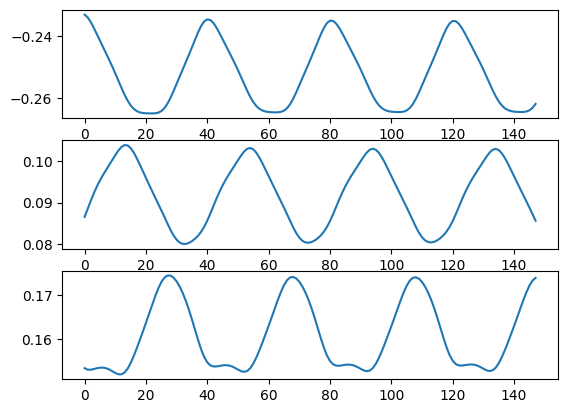

In [32]:
import pysindy as ps
from pysindy.differentiation import FiniteDifference
gru_outs, sindy_outs = shred.gru_outputs(test_dataset.X[:150,:], sindy=True)
differentiation_method = FiniteDifference()

fig, ax = plt.subplots(latent_dim)
for i in range(latent_dim):
    ax[i].plot(gru_outs[1:,0,i].detach().cpu().numpy())

### Model discovery with SINDy

The following code block extracts latent states using a GRU model. Each of the first three dimensions is normalized and re-scaled to [-1,1]. A SINDy model is then set up with a polynomial library. This SINDy model is fitted to the data and later used to simulate the dynamics for comparison with the original GRU latent trajectories.

The hyperparameters for the SINDy model are set as follows:
- **Differentiation Method:** Finite difference is used to compute numerical derivatives. When the latent states trajectories are noisy, one should consider to use ps.differentiation.SmoothedFiniteDifference().
- **Optimizer Sequantially thresholded least-squares: STLSQ:**  
  - *Threshold:* 0.8, which controls the sparsity level by eliminating coefficients below this value.
  - *Alpha:* 0.05, L2 regularization.
- **Optimizer Mixed-interger optimization: MIOSR:**  
  - *group_sparsity:* how many termseach equations should include.
- **Feature Library:** Here we only include polynomial features up to degree 1, ensuring only linear terms are considered in the model. Practically this could set up to degree 3 which will include more nonlinear terms.

For model selection, a simple baseline standard is to visually examine how the long-term extrapolation behaves. We can pick the model that fits the data well. It is also possible to include metrics (like the MSE) to quantitatively measure these quantities.

In [115]:
# Parameters
time_steps = 150
latent_dim = 3
poly_order = 2
threshold = 0.005
alpha = 0.05
dt = 0.2

# Get GRU outputs for the entire dataset
gru_outs_full, sindy_outs = shred.gru_outputs(train_dataset.X, sindy=True)
gru_outs_full = gru_outs_full[:, 0, :]  # Shape: (total_time_steps, latent_dim)
sindy_outs = sindy_outs[:, 0, :]

# Calculate number of trajectories
total_time_steps = gru_outs_full.shape[0]
num_trajectories = total_time_steps // time_steps

# Collect multiple trajectories
all_gru_outs = []
all_sindy_outs = []
for traj_idx in range(num_trajectories):
    start_idx = traj_idx * time_steps
    end_idx = (traj_idx + 1) * time_steps
    gru_outs = gru_outs_full[start_idx:end_idx, :]
    sindy_traj_outs = sindy_outs[start_idx:end_idx, :]

    all_gru_outs.append(gru_outs.detach().cpu().numpy())  # Convert to numpy
    all_sindy_outs.append(sindy_traj_outs.detach().cpu().numpy())


# SINDy model setup
differentiation_method = ps.differentiation.FiniteDifference()
model = ps.SINDy(
    optimizer=ps.STLSQ(threshold=threshold, alpha=0.05),
    differentiation_method=differentiation_method,
    feature_library=ps.PolynomialLibrary(degree=poly_order)
)

# Fit SINDy model
model.fit(x=all_gru_outs, t=dt, ensemble=False, multiple_trajectories=True)
model.print()

# Simulate one trajectory
t_train = np.arange(0, time_steps * dt, dt)
init_cond = all_gru_outs[0][0, :]
x_sim = model.simulate(init_cond, t_train)

# Plot results
fig, ax = plt.subplots(latent_dim, 1, figsize=(10, 2 * latent_dim))
for i in range(latent_dim):
    ax[i].plot(t_train, all_gru_outs[0][:, i], label="GRU Output", color="blue")
    ax[i].plot(t_train, all_sindy_outs[0][:, i], label="SINDy Output", color="green")
    ax[i].plot(t_train, x_sim[:, i], "--", label="SINDy Model", color="black")
    ax[i].set_xlabel("Time")
    ax[i].set_ylabel(f"Latent dim {i+1}")
    ax[i].legend()
    ax[i].grid(True)
plt.tight_layout()
plt.show()


(x0)' = 6.961 1 + -117.583 x0 + -151.807 x1 + -181.563 x2 + 296.380 x0^2 + 1008.046 x0 x1 + 1068.584 x0 x2 + 730.532 x1^2 + 1660.333 x1 x2 + 915.611 x2^2
(x1)' = -3.578 1 + 55.642 x0 + 74.254 x1 + 89.634 x2 + -207.128 x0^2 + -571.909 x0 x1 + -661.967 x0 x2 + -376.224 x1^2 + -921.607 x1 x2 + -532.014 x2^2
(x2)' = -3.943 1 + 75.796 x0 + 95.215 x1 + 110.821 x2 + -80.700 x0^2 + -491.172 x0 x1 + -436.062 x0 x2 + -435.681 x1^2 + -846.570 x1 x2 + -435.427 x2^2


ValueError: Input contains infinity or a value too large for dtype('float64').

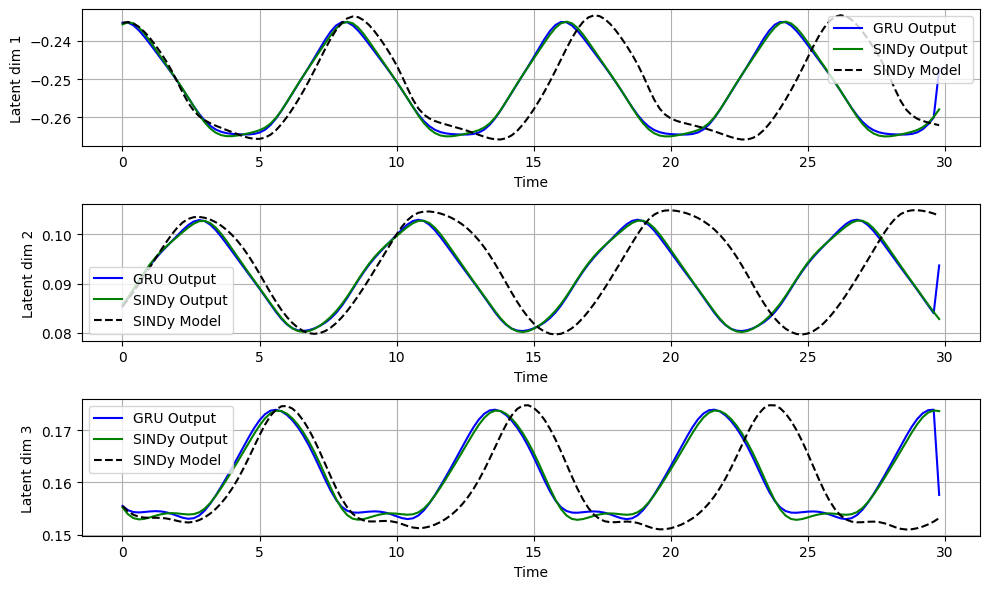

In [114]:
# Simulate one trajectory
num = 22
t_train = np.arange(0, time_steps * dt, dt)
init_cond = all_gru_outs[num][0, :]
x_sim = model.simulate(init_cond, t_train)

# Plot results
fig, ax = plt.subplots(latent_dim, 1, figsize=(10, 2 * latent_dim))
for i in range(latent_dim):
    ax[i].plot(t_train, all_gru_outs[num][:, i], label="GRU Output", color="blue")
    ax[i].plot(t_train, all_sindy_outs[num][:, i], label="SINDy Output", color="green")
    ax[i].plot(t_train, x_sim[:, i], "--", label="SINDy Model", color="black")
    ax[i].set_xlabel("Time")
    ax[i].set_ylabel(f"Latent dim {i+1}")
    ax[i].legend()
    ax[i].grid(True)
plt.tight_layout()
plt.show()

##### Reload data from the entire training set

In [ ]:
gru_outs_train, _ = shred.gru_outputs(train_dataset.X, sindy=True)
gru_outs_train = gru_outs_train[:,0,:]
gru_outs_val, _ = shred.gru_outputs(valid_dataset.X, sindy=True)
gru_outs_val = gru_outs_val[:,0,:]
gru_outs_test, _ = shred.gru_outputs(test_dataset.X, sindy=True)
gru_outs_test = gru_outs_test[:,0,:]

In [ ]:
gru_outs_all = np.zeros((1345, 3))
gru_outs_all[:999,:] = gru_outs_train.detach().cpu().numpy()
gru_outs_all[999:1028,:] = gru_outs_val.detach().cpu().numpy()
gru_outs_all[1028:,:] = gru_outs_test.detach().cpu().numpy()

gru_outs_numpy = gru_outs_train.detach().cpu().numpy()

# issue normalization should be done on the training dataset only ??

gru_outs_all[:,0] = (gru_outs_all[:,0] - np.min(gru_outs_numpy[:,0])) / (np.max(gru_outs_numpy[:,0])-np.min(gru_outs_numpy[:,0]))
gru_outs_all[:,1] = (gru_outs_all[:,1] - np.min(gru_outs_numpy[:,1])) / (np.max(gru_outs_numpy[:,1])-np.min(gru_outs_numpy[:,1]))
gru_outs_all[:,2] = (gru_outs_all[:,2] - np.min(gru_outs_numpy[:,2])) / (np.max(gru_outs_numpy[:,2])-np.min(gru_outs_numpy[:,2]))

gru_outs_all = 2 * gru_outs_all - 1

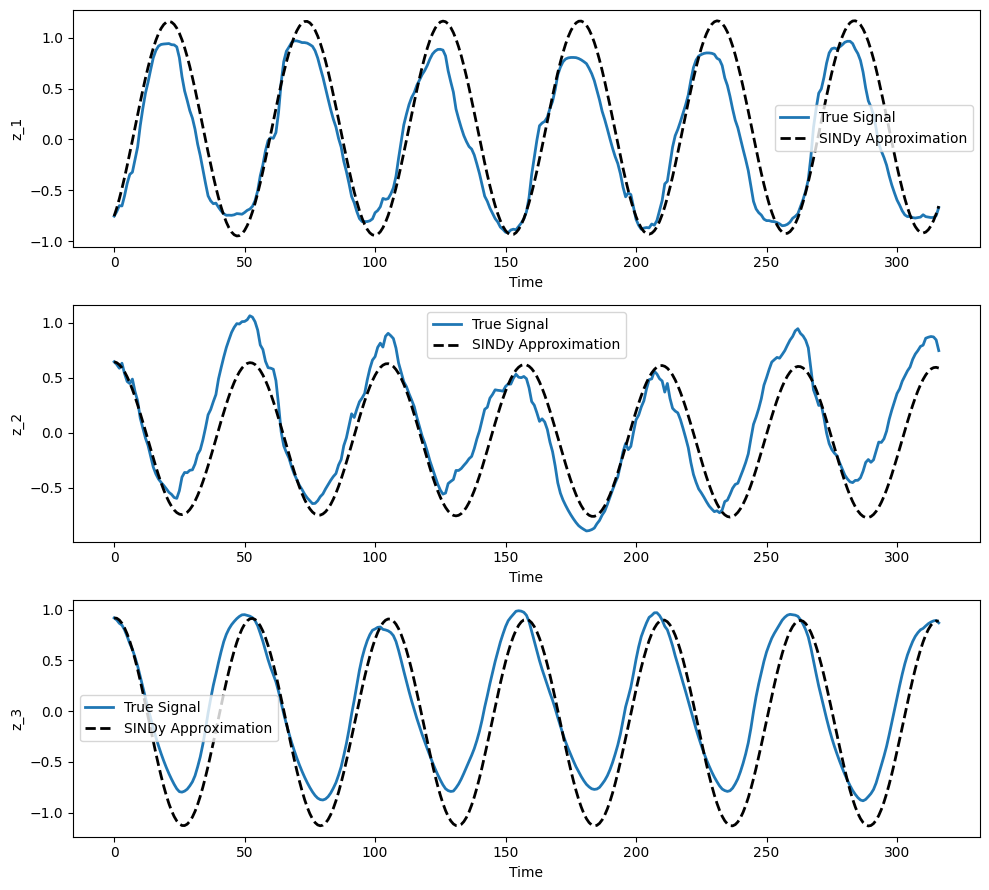

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.io import loadmat



###############Normalization###############
gru_outs_test_np = gru_outs_test.detach().cpu().numpy()

gru_outs_test_np[:, 0] = (gru_outs_test_np[:, 0] - np.min(gru_outs_numpy[:, 0])) / (np.max(gru_outs_numpy[:, 0]) - np.min(gru_outs_numpy[:, 0]))
gru_outs_test_np[:, 1] = (gru_outs_test_np[:, 1] - np.min(gru_outs_numpy[:, 1])) / (np.max(gru_outs_numpy[:, 1]) - np.min(gru_outs_numpy[:, 1]))
gru_outs_test_np[:, 2] = (gru_outs_test_np[:, 2] - np.min(gru_outs_numpy[:, 2])) / (np.max(gru_outs_numpy[:, 2]) - np.min(gru_outs_numpy[:, 2]))

gru_outs_test_np = 2 * gru_outs_test_np - 1  # Transform to [-1, 1]

################Forward simulation with the model################
t_train = np.arange(0, 317*1/52.0, 1/52.0)
init_cond = np.zeros(latent_dim)
init_cond[:latent_dim] = gru_outs_test_np[0, :]
x_sim_test = model.simulate(init_cond, t_train)

# Plotting for each latent dimension: True vs SINDy
fig, ax = plt.subplots(latent_dim, figsize=(10, latent_dim * 3))

for i in range(latent_dim):
    ax[i].plot(gru_outs_test_np[:, i], label='True Signal', linewidth=2)
    ax[i].plot(x_sim_test[:, i], "k--", label='SINDy Approximation', linewidth=2)
    ax[i].legend()
    ax[i].set_ylabel(f'z_{i+1}')
    ax[i].set_xlabel('Time')

plt.tight_layout()
plt.show()

###############Predict back in the pixel space###############

# Step 1: Revert the normalization to original scale
gru_outs_test_np = (gru_outs_test_np + 1) / 2  # Revert from [-1, 1] to [0, 1]

for i in range(3):  # Assuming 3 latent dimensions for this example
    gru_outs_test_np[:, i] = gru_outs_test_np[:, i] * (np.max(gru_outs_numpy[:, i]) - np.min(gru_outs_numpy[:, i])) + np.min(gru_outs_numpy[:, i])

# Step 2: Decoder reconstruction using the decoder model
latent_pred = torch.FloatTensor(gru_outs_test_np).cuda()

# Pass through the decoder
output = shred.linear1(latent_pred)
output = shred.dropout(output)
output = torch.nn.functional.relu(output)
output = shred.linear2(output)
output = shred.dropout(output)
output = torch.nn.functional.relu(output)
output = shred.linear3(output)

output_np = output.detach().cpu().numpy()

In [ ]:
###############Plotting settings###############
load_X = loadmat('Data/SST_data.mat')['Z'].T
mean_X = np.mean(load_X, axis=0)
sst_locs = np.where(mean_X != 0)[0]
reconstructed_data = np.zeros_like(load_X[0, :])
reconstructed_data[sst_locs] = output_np[0, :]  # Assuming first timestep
reshaped_reconstructed = reconstructed_data.reshape(180, 360)

26.60741


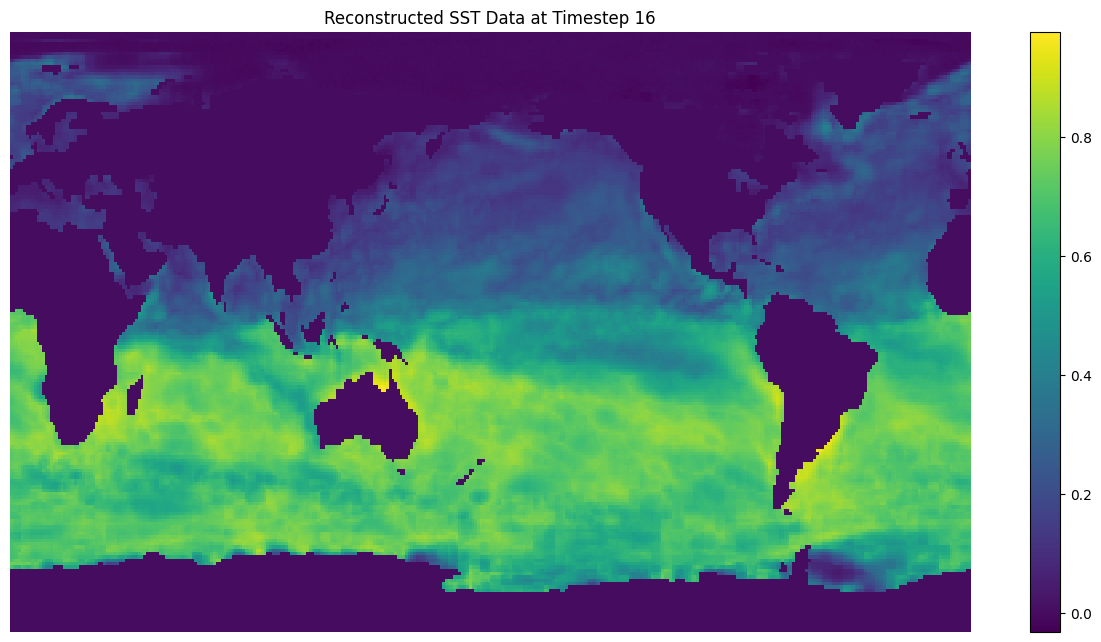

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.io import loadmat

def reconstruct_and_plot_sindy(x_sim_test, gru_outs_numpy, decoder_model, sst_data_path, timesteps):
    """
    Reconstructs and visualizes data using SINDy-simulated latent space for multiple timesteps.

    Args:
        x_sim_test (np.array): SINDy-simulated latent space.
        gru_outs_numpy (np.array): The original latent space for Min-Max scaling reversal.
        decoder_model (nn.Module): The decoder model for reconstruction.
        sst_data_path (str): Path to the SST data file.
        timesteps (list of int): List of timesteps to plot.

    Returns:
        None. It generates and shows the plots.
    """
    # Step 1: Reverse Min-Max scaling for SINDy-simulated data (x_sim_test)
    x_sim_test = np.array(x_sim_test)  # Ensure it's a numpy array if needed

    # Revert the scaling from [-1, 1] back to [0, 1]
    x_sim_test = (x_sim_test + 1) / 2

    # Perform the Min-Max reverse transformation using the original min/max values
    for i in range(3):  # Assuming 3 latent dimensions, need to be updated
        x_sim_test[:, i] = x_sim_test[:, i] * (np.max(gru_outs_numpy[:, i]) - np.min(gru_outs_numpy[:, i])) + np.min(gru_outs_numpy[:, i])

    # Perform the decoder reconstruction using the transformed SINDy-simulated data
    latent_pred_sindy = torch.FloatTensor(x_sim_test).cuda()  # Convert to torch tensor for reconstruction

    # Pass the SINDy-simulated latent space data through the decoder
    output_sindy = decoder_model.linear1(latent_pred_sindy)
    output_sindy = decoder_model.dropout(output_sindy)
    output_sindy = torch.nn.functional.relu(output_sindy)
    output_sindy = decoder_model.linear2(output_sindy)
    output_sindy = decoder_model.dropout(output_sindy)
    output_sindy = torch.nn.functional.relu(output_sindy)
    output_sindy = decoder_model.linear3(output_sindy)

    # Detach and convert the reconstructed data back to numpy for visualization
    output_sindy_np = output_sindy.detach().cpu().numpy()
    load_X = loadmat(sst_data_path)['Z'].T
    mean_X = np.mean(load_X, axis=0)
    sst_locs = np.where(mean_X != 0)[0]

    # Prepare the SST data reconstruction and plot for each timestep
    for t in timesteps:
        # Initialize an empty array with the same shape as the original SST data
        reconstructed_data_sindy = np.zeros_like(load_X[0, :])

        # Copy the SINDy-reconstructed values back to the SST locations for the current timestep
        reconstructed_data_sindy[sst_locs] = output_sindy_np[t, :]  # Use the selected timestep
        print(np.sum(np.square(output_sindy_np[t,:]-output_sindy_np[t+1, :])))

        # Reshape the SST data back to its original 2D form (180, 360)
        reshaped_reconstructed_sindy = reconstructed_data_sindy.reshape(180, 360)

        # Step 5: Visualization of the SST data reconstructed using the SINDy-simulated latent space
        plt.figure(figsize=(12, 6))
        plt.imshow(reshaped_reconstructed_sindy, aspect='auto', interpolation='nearest')
        plt.colorbar()  # Add a color bar to show the value range

        # Remove axes, ticks, and background for a clean image
        plt.gca().set_axis_off()

        # Show the plot with transparent background
        plt.tight_layout(pad=0)
        plt.title(f'Reconstructed SST Data at Timestep {t}')
        plt.show()
    return output_sindy_np

# Example usage
# Assuming decoder_model is your decoder, and timesteps are [0, 10, 50] or any set of timesteps you'd like to plot
timesteps = [16]  # Define timesteps to plot
output_sindy_np = reconstruct_and_plot_sindy(x_sim_test, gru_outs_numpy, shred, 'Data/SST_data.mat', timesteps)


### Comparing the true data to predictions

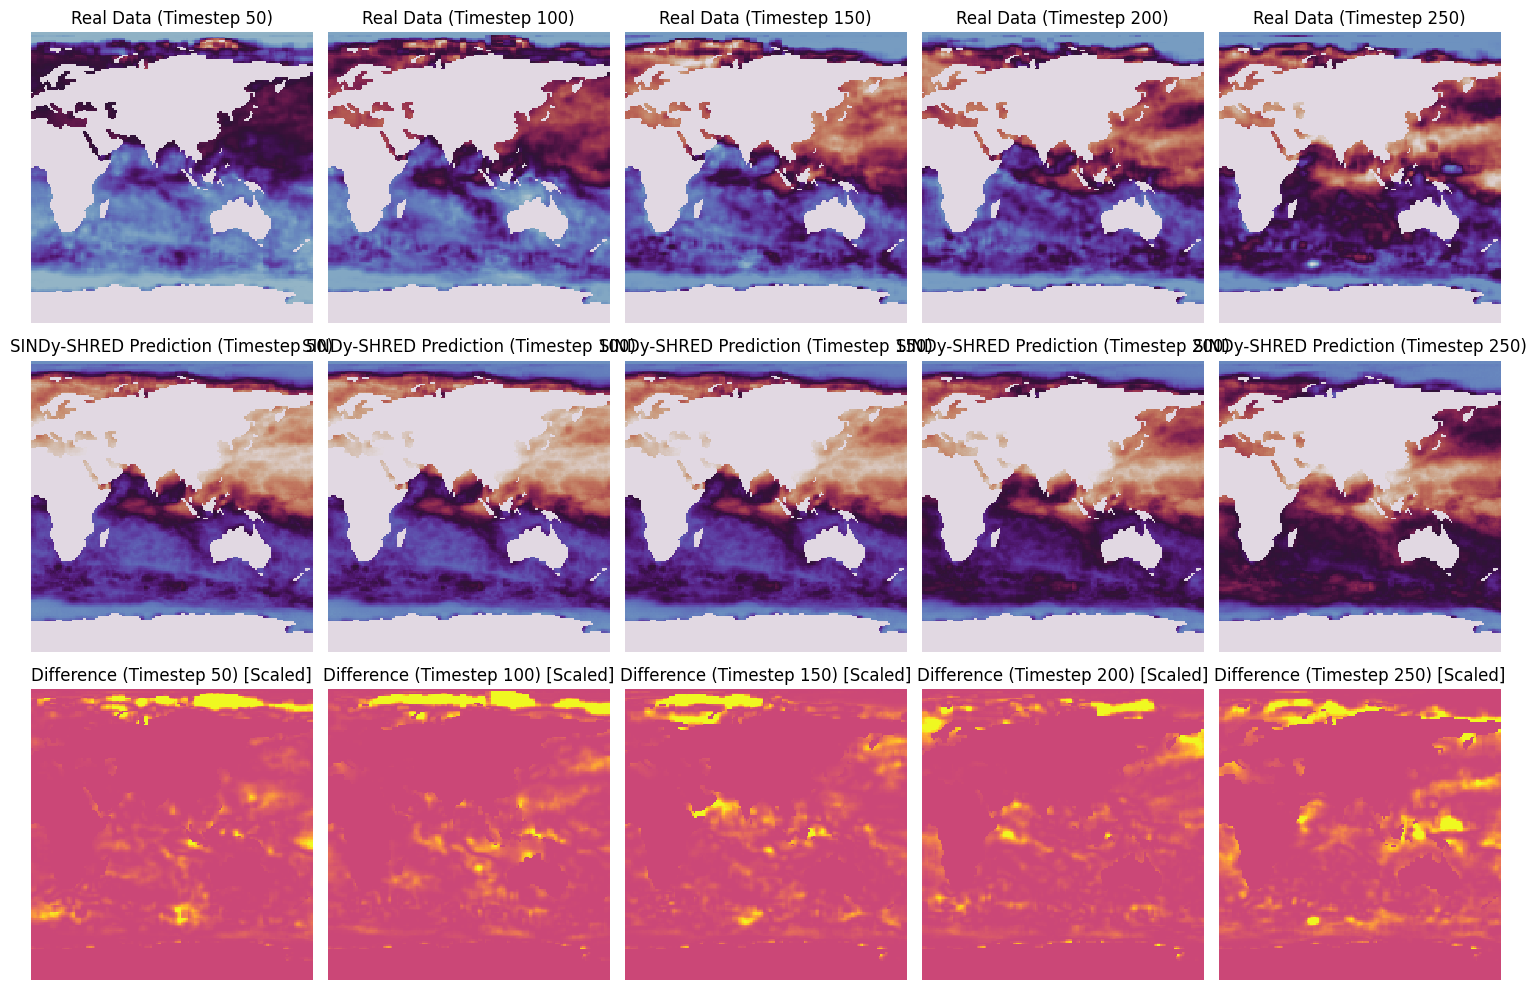

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_zoomed_comparison(real_data, sindy_data, sst_locs, timesteps, lat_range, lon_range, diff_scale=10):
    """
    Plot the real SST data, SINDy-SHRED predictions, and their differences in a specific area (zoomed).
    The difference is amplified by a scaling factor to make it clearer.

    Args:
        real_data (np.array): The ground truth SST data.
        sindy_data (np.array): The SINDy-SHRED reconstructed data.
        sst_locs (np.array): Indices of non-zero SST locations.
        timesteps (list of int): List of timesteps to visualize.
        lat_range (tuple): Latitude range for zoom (e.g., (start_lat, end_lat)).
        lon_range (tuple): Longitude range for zoom (e.g., (start_lon, end_lon)).
        diff_scale (float): Scaling factor for amplifying the difference plot.

    Returns:
        None. Displays the comparison plots.
    """
    num_plots = len(timesteps)

    fig, axes = plt.subplots(3, num_plots, figsize=(15, 10))

    real_data_inverse_transformed = sc.inverse_transform(real_data)
    sindy_data_inverse_transformed = sc.inverse_transform(sindy_data)
    for i, t in enumerate(timesteps):
        # Plot Real Data
        real_sst = np.zeros((180 * 360))-0.25
        real_sst[sst_locs] = 1*(real_data[t, :])
        reshaped_real_sst = real_sst.reshape(180, 360)

        # Select the region of interest (lat_range, lon_range)
        real_sst_zoomed = reshaped_real_sst[lat_range[0]:lat_range[1], lon_range[0]:lon_range[1]]
        axes[0, i].imshow(real_sst_zoomed, aspect='auto', cmap='twilight', interpolation='none')
        axes[0, i].set_title(f'Real Data (Timestep {t})')
        axes[0, i].set_axis_off()

        # Plot SINDy-SHRED Prediction
        sindy_sst = np.zeros((180 * 360))-0.25
        sindy_sst[sst_locs] = 1*(sindy_data[t, :])
        reshaped_sindy_sst = sindy_sst.reshape(180, 360)

        # Select the region of interest (lat_range, lon_range)
        sindy_sst_zoomed = reshaped_sindy_sst[lat_range[0]:lat_range[1], lon_range[0]:lon_range[1]]
        axes[1, i].imshow(sindy_sst_zoomed, aspect='auto', cmap='twilight', interpolation='none')
        axes[1, i].set_title(f'SINDy-SHRED Prediction (Timestep {t})')
        axes[1, i].set_axis_off()

        # Plot Difference (Real - SINDy) with scaling factor
        diff_sst_zoomed = 10*np.square(real_sst_zoomed - sindy_sst_zoomed)
        axes[2, i].imshow(diff_sst_zoomed, aspect='auto', cmap='plasma', interpolation='none', vmin=-1, vmax=1)  # Blue-White-Red for differences
        axes[2, i].set_title(f'Difference (Timestep {t}) [Scaled]')
        axes[2, i].set_axis_off()

    # Adjust layout
    plt.tight_layout()
    plt.show()

# Example usage:
timesteps = [50, 100, 150, 200, 250]  # Define the timesteps you want to compare
lat_range = (0, 180)  # Define the latitude range to zoom in (adjust based on your grid)
lon_range = (0, 180)  # Define the longitude range to zoom in (adjust based on your grid)
plot_zoomed_comparison(test_dataset.Y.detach().cpu().numpy(), output_sindy_np, sst_locs, timesteps, lat_range, lon_range, diff_scale=10)


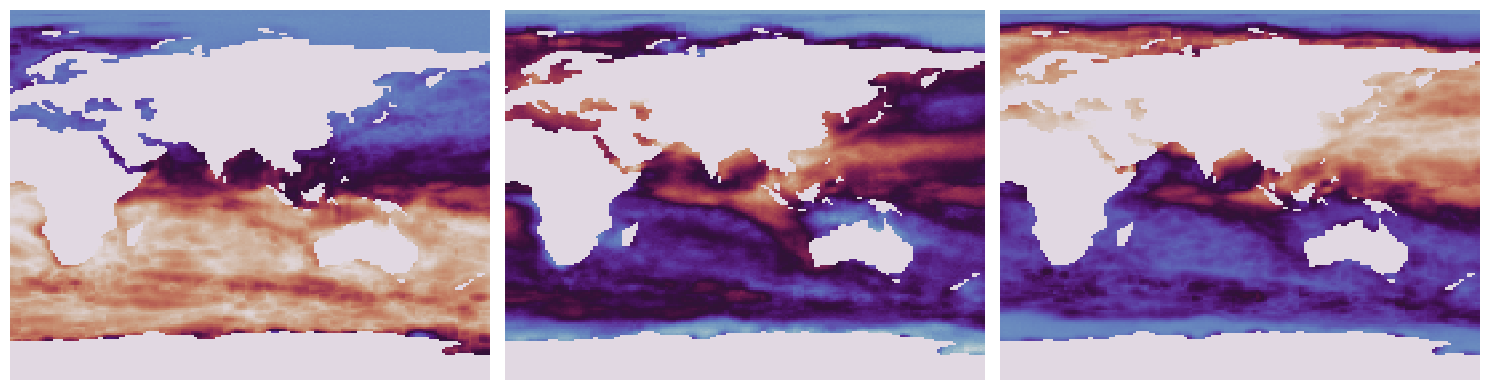

In [ ]:
def plot_rescaled_latent_reconstructions(decoder_model, sst_data_path, gru_outs_numpy):
    """
    Rescales and plots the decoder reconstruction for specific latent space vectors (1,0,0), (0,1,0), and (0,0,1).
    Keeps consistent numerical scales and visualization styles.

    Args:
        decoder_model (nn.Module): The decoder model for reconstruction.
        sst_data_path (str): Path to the SST data file.
        gru_outs_numpy (np.array): Original latent space data for Min-Max scaling reversal.

    Returns:
        None. Displays the plots.
    """
    # Define the specific latent space vectors
    latent_vectors = np.eye(3)  # (1,0,0), (0,1,0), (0,0,1)
    # Convert latent vectors to a torch tensor
    latent_vectors_tensor = torch.FloatTensor(latent_vectors).cuda()

    for i in range(3):  # Assuming 3 latent dimensions
        latent_vectors_tensor[:, i] = latent_vectors_tensor[:, i] * (np.max(gru_outs_numpy[:, i]) - np.min(gru_outs_numpy[:, i])) + np.min(gru_outs_numpy[:, i])

    # Perform reconstruction using the decoder
    output_reconstructed = decoder_model.linear1(latent_vectors_tensor)
    output_reconstructed = decoder_model.dropout(output_reconstructed)
    output_reconstructed = torch.nn.functional.relu(output_reconstructed)
    output_reconstructed = decoder_model.linear2(output_reconstructed)
    output_reconstructed = decoder_model.dropout(output_reconstructed)
    output_reconstructed = torch.nn.functional.relu(output_reconstructed)
    output_reconstructed = decoder_model.linear3(output_reconstructed)

    # Convert reconstructed data back to numpy
    output_reconstructed_np = output_reconstructed.detach().cpu().numpy()

    # Load the SST data to determine grid locations
    load_X = loadmat(sst_data_path)['Z'].T
    mean_X = np.mean(load_X, axis=0)
    sst_locs = np.where(mean_X != 0)[0]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Plot each reconstructed result
    for i, vec in enumerate(latent_vectors):
        # Initialize an empty array for the entire SST grid
        reconstructed_sst = np.zeros_like(load_X[0, :]) - 0.25

        # Fill the SST grid with the reconstructed values
        reconstructed_sst[sst_locs] = output_reconstructed_np[i, :]

        # Reshape the SST data to 2D (180, 360)
        reshaped_sst = reconstructed_sst.reshape(180, 360)

        reshaped_sst = reshaped_sst[lat_range[0]:lat_range[1], lon_range[0]:lon_range[1]]
        axes[i].imshow(reshaped_sst, aspect='auto', cmap='twilight', interpolation='none')
        axes[i].set_axis_off()

    plt.tight_layout()
    plt.show()

plot_rescaled_latent_reconstructions(
    decoder_model=shred,
    sst_data_path='Data/SST_data.mat',
    gru_outs_numpy=gru_outs_numpy
)


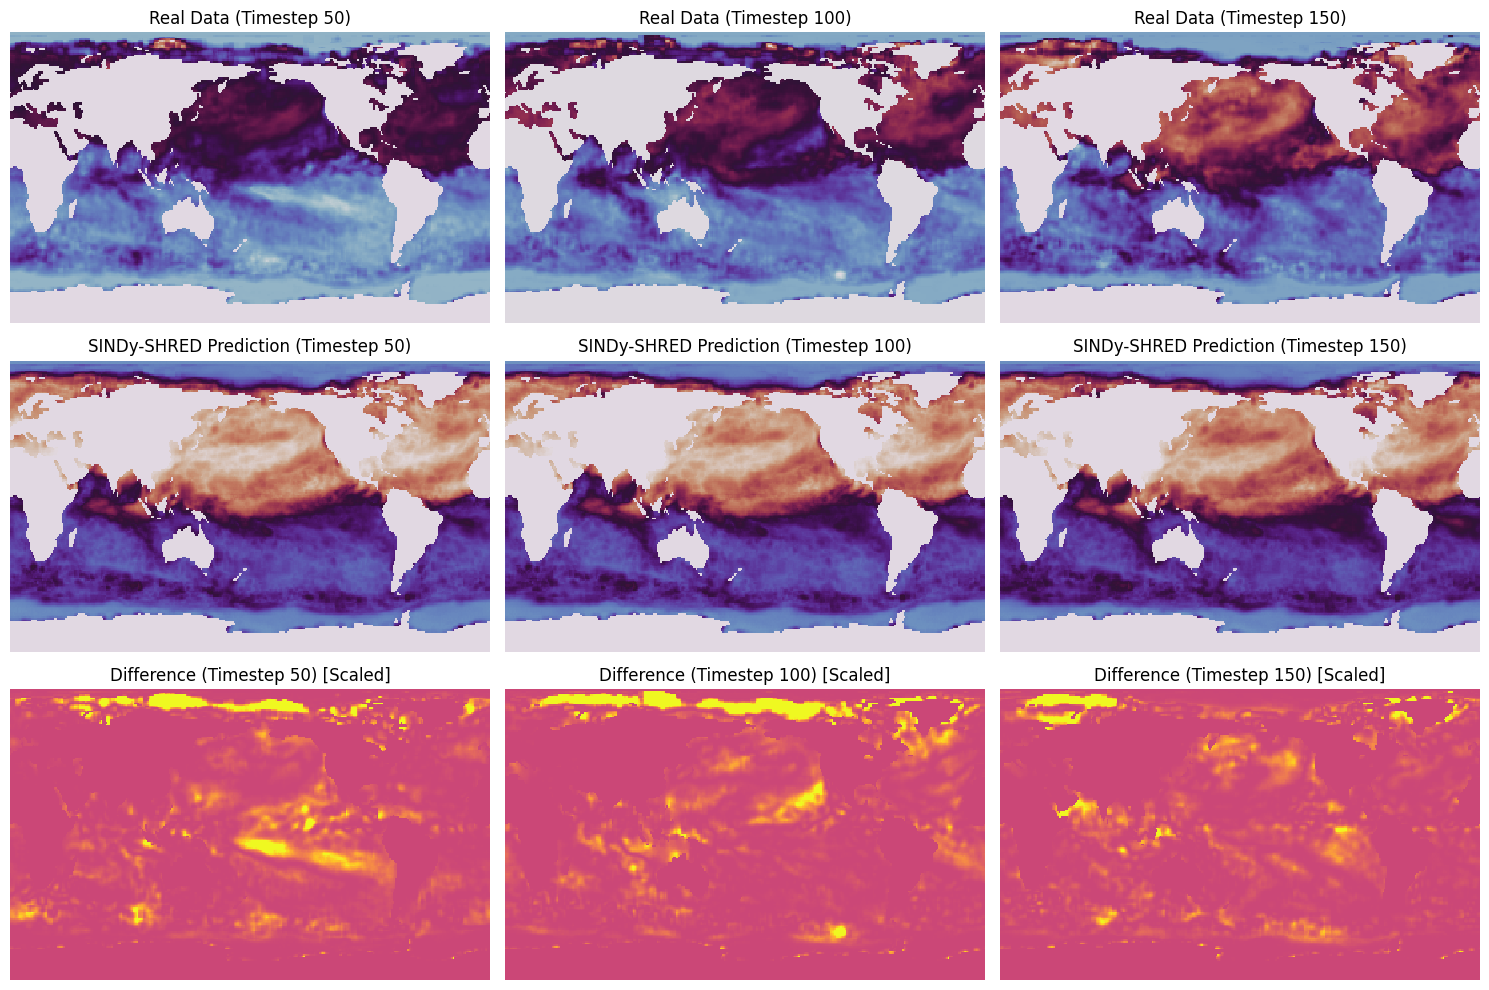

In [ ]:
# Example usage:
timesteps = [50, 100, 150]  # Define the timesteps you want to compare
lat_range = (0, 180)  # Define the latitude range to zoom in (adjust based on your grid)
lon_range = (0, 360)  # Define the longitude range to zoom in (adjust based on your grid)
plot_zoomed_comparison(test_dataset.Y.detach().cpu().numpy(), output_sindy_np, sst_locs, timesteps, lat_range, lon_range, diff_scale=10)

### Sensor-level plots

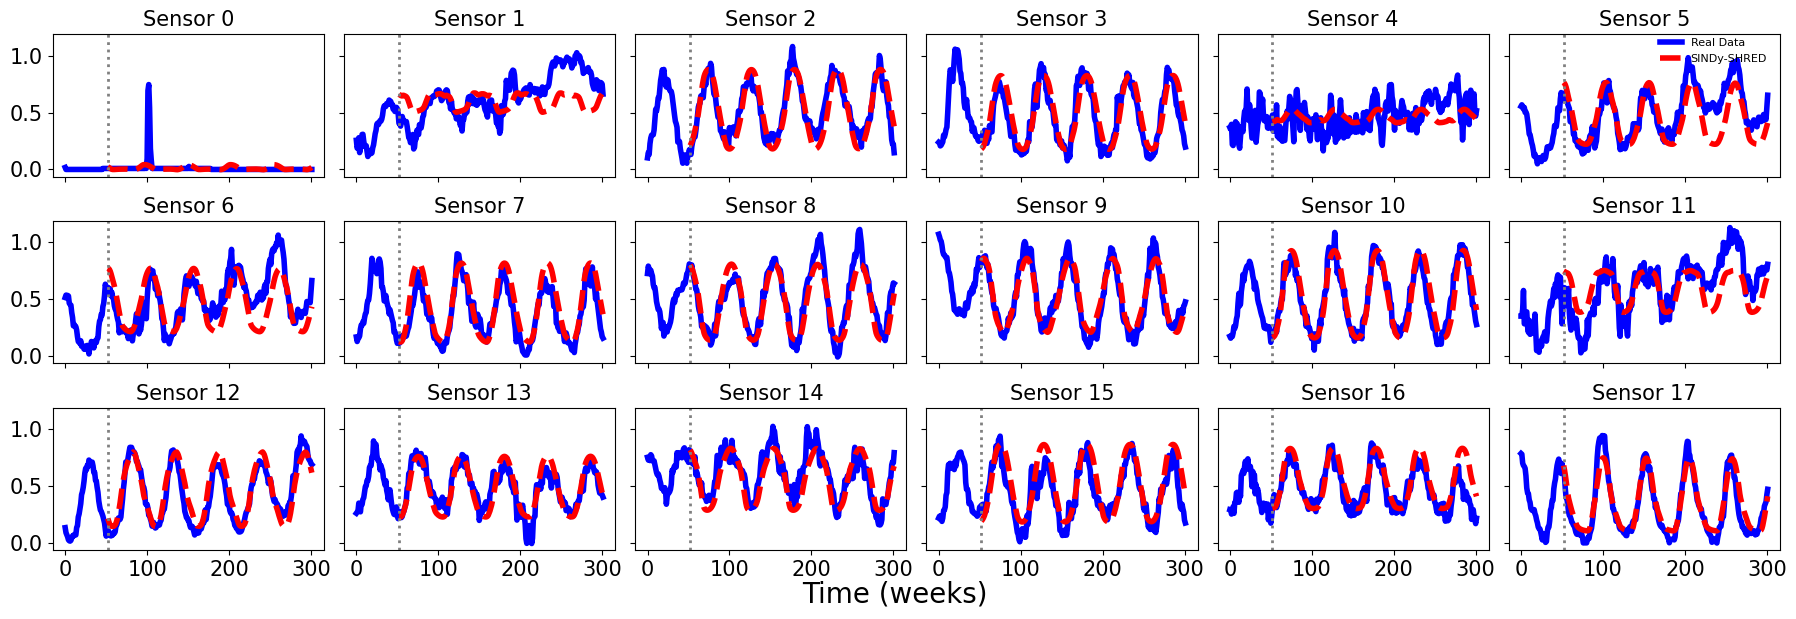

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_multiple_sensor_predictions(real_data, sindy_data, sensor_locations, sensor_indices, num_train=52, num_pred=250, rows=4, cols=4):
    """
    Plot the real data and SINDy-SHRED prediction for multiple sensors in a grid layout.

    Args:
        real_data (np.array): The real SST data.
        sindy_data (np.array): The predicted data from SINDy-SHRED.
        sensor_locations (np.array): Sensor locations (indices) used in training.
        sensor_indices (list): Indices of the sensors to visualize.
        num_train (int): Number of training data points (default is 100).
        num_pred (int): Number of prediction data points (default is 100).
        rows (int): Number of rows in the grid layout.
        cols (int): Number of columns in the grid layout.

    Returns:
        None. Displays and saves the plot.
    """
    num_sensors = len(sensor_indices)
    fig, axes = plt.subplots(rows, cols, figsize=(3*cols, 2*rows), sharex=True, sharey=True)
    axes = axes.flatten()  # Flatten the 2D array of axes for easy indexing

    for i, sensor_idx in enumerate(sensor_indices):
        if i >= rows * cols:
            break  # Stop if we've exceeded the number of subplots

        sensor = sensor_locations[sensor_idx]

        # Real data for the training period
        sensor_real_data = real_data[:num_train+num_pred, sensor]

        # SINDy-SHRED prediction for the prediction period
        sensor_pred_data = sindy_data[num_train:num_train+num_pred, sensor]

        axes[i].plot(np.arange(num_train+num_pred), sensor_real_data, color="blue", linewidth=4)
        axes[i].plot(np.arange(num_train, num_train+num_pred), sensor_pred_data, color="red", linestyle="--", linewidth=4)

        axes[i].set_title(f'Sensor {sensor_idx}', fontsize=15)
        axes[i].tick_params(axis='both', which='major', labelsize=15)

        # Add a vertical line to separate training and prediction periods
        axes[i].axvline(x=num_train, color='gray', linestyle=':', linewidth=2)

    # Remove any unused subplots
    for i in range(num_sensors, rows * cols):
        fig.delaxes(axes[i])

    # Add labels and title
    fig.text(0.5, 0.0, 'Time (weeks)', ha='center', va='center', fontsize=20)
#     fig.text(0.02, 0.5, 'Sensor Value', ha='center', va='center', rotation='vertical', fontsize=10)
#     fig.suptitle("Real Data (blue) vs SINDy-SHRED Prediction (red dashed)", fontsize=14)

    # Add a common legend
    lines = [plt.Line2D([0], [0], color="blue", lw=4),
             plt.Line2D([0], [0], color="red", linestyle="--", lw=4)]
    labels = ["Real Data", "SINDy-SHRED"]
    fig.legend(lines, labels, loc="upper right", bbox_to_anchor=(0.99, 0.945), fontsize=8, frameon=False)

    plt.tight_layout()
    plt.savefig('sensor_predictions_grid.pdf', format='pdf', bbox_inches='tight', dpi=300)
    plt.show()

# Example usage:
sensor_locations_test = np.random.randint(1, 40000, size=18)
sensor_indices = list(range(0, 18, 1))  # Choose 32 sensors (0, 5, 10, ..., 155)
plot_multiple_sensor_predictions(test_dataset.Y.detach().cpu().numpy(), output_sindy_np, sensor_locations_test, sensor_indices, rows=3, cols=6)